In [25]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import shap


c:\Users\Allan\Desktop\Faculdade\PISI3\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
df = pd.read_csv('..\datasets\df_cluster.csv')

CLUSTER_FEATURES = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'valence',
    'tempo'
]

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Allan\AppData\Local\Temp\ipykernel_1536\99134906.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('..\datasets\df_cluster.csv')


# Box Plots

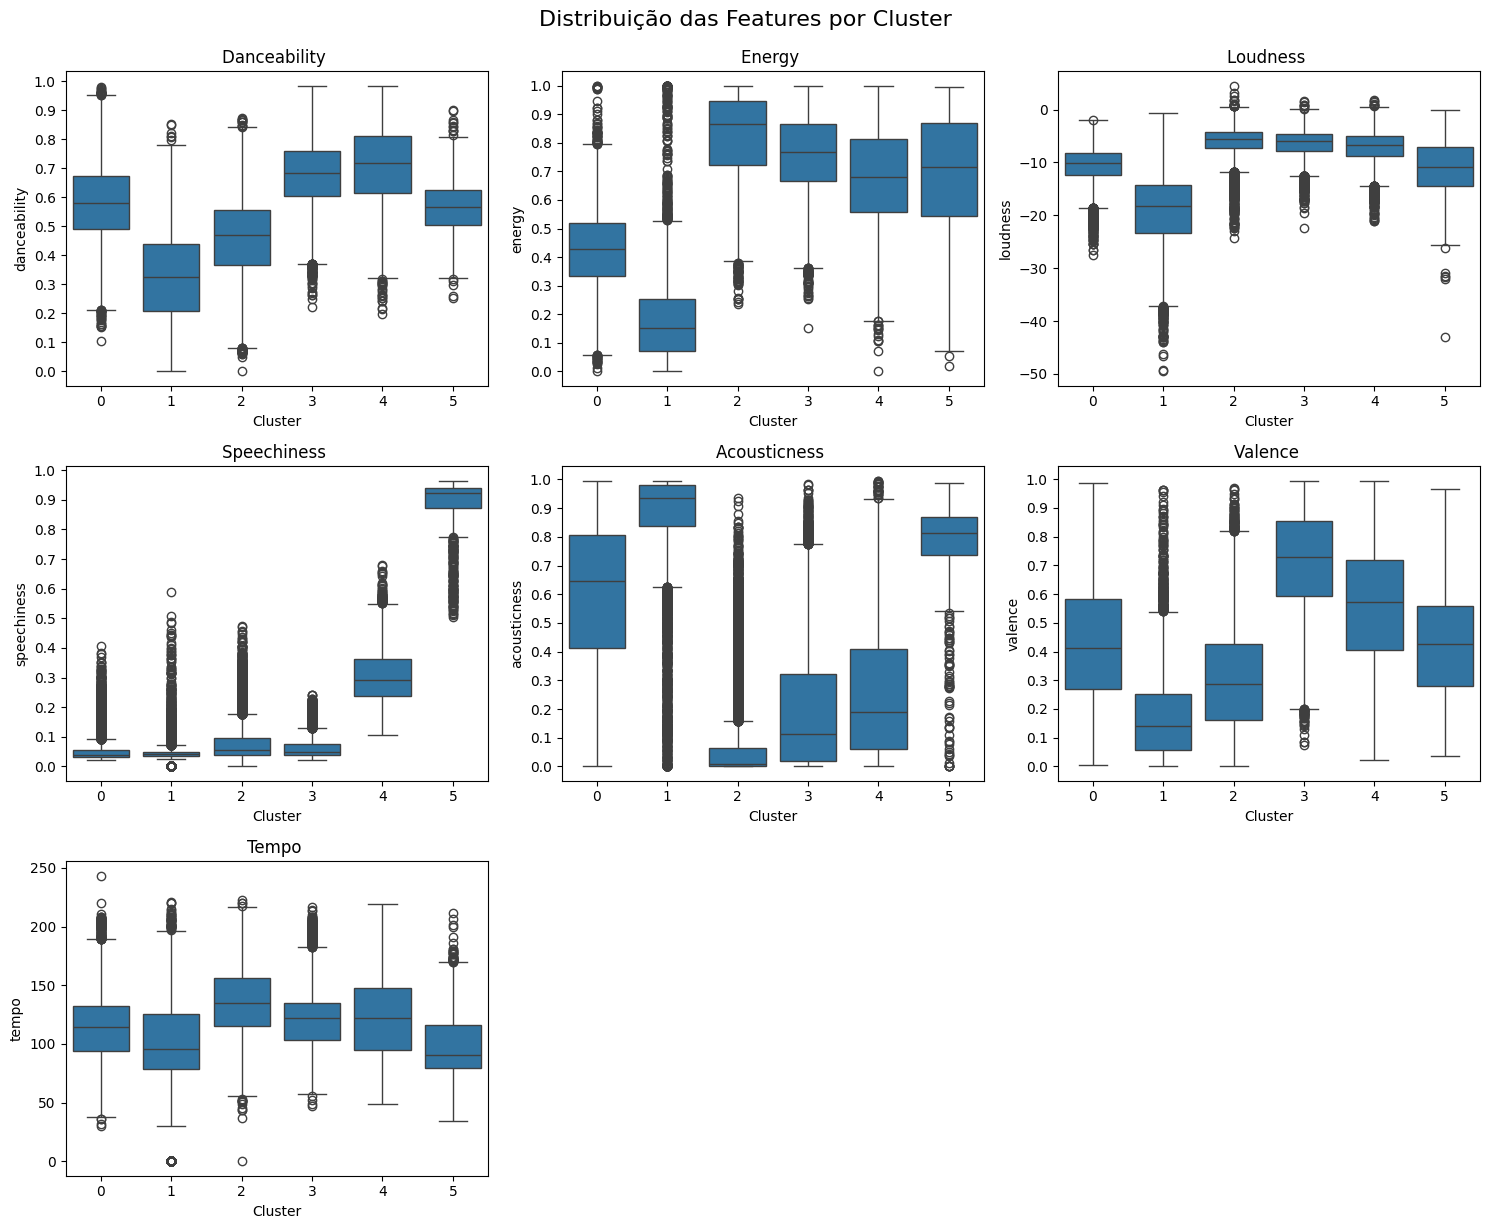

In [ ]:

n_cols = 3
n_rows = (len(CLUSTER_FEATURES) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, feature in enumerate(CLUSTER_FEATURES, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=df, x='cluster', y=feature)
    plt.title(f'{feature.capitalize()} ')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    
    # Define ticks do eixo Y de 0.0 até 1.0 com passo 0.1 (ajuste se necessário)
    min_val = df[feature].min()
    max_val = df[feature].max()
    
    # Só aplica se o range for compatível (evita erro no loudness ou tempo)
    if max_val - min_val < 2:
        plt.yticks(np.arange(0.0, 1.05, 0.1))

plt.tight_layout()
plt.suptitle('Distribuição das Features por Cluster', fontsize=16, y=1.02)
plt.show()


# Shap dos Clusters

In [27]:
X = df[CLUSTER_FEATURES]
y = df['cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

shap.plots.waterfall(shap_values[0])

100%|===================| 122008/122016 [142:37<00:00]        

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 0.369900, while the model output was 0.400000. If this difference is acceptable you can set check_additivity=False to disable this check.